# <u> **Does Coffee Consumption Cause Higher Heart Rate?**

### **Dataset Used:**

https://www.kaggle.com/datasets/uom190346a/global-coffee-health-dataset

### **Dataset Description:**

**Global Coffee Health Dataset**

**Description:** The GlobalCoffeeHealth dataset contains 10,000 synthetic records reflecting real-world patterns of coffee consumption, sleep behavior, and health outcomes across 20 countries. It includes demographics, daily coffee intake, caffeine levels, sleep duration and quality, BMI, heart rate, stress, physical activity, health issues, occupation, smoking, and alcohol consumption. The dataset captures realistic correlations observed in research—such as caffeine’s impact on sleep, stress, and health—making it ideal for statistical analysis, predictive modeling, and lifestyle or wellness studies.

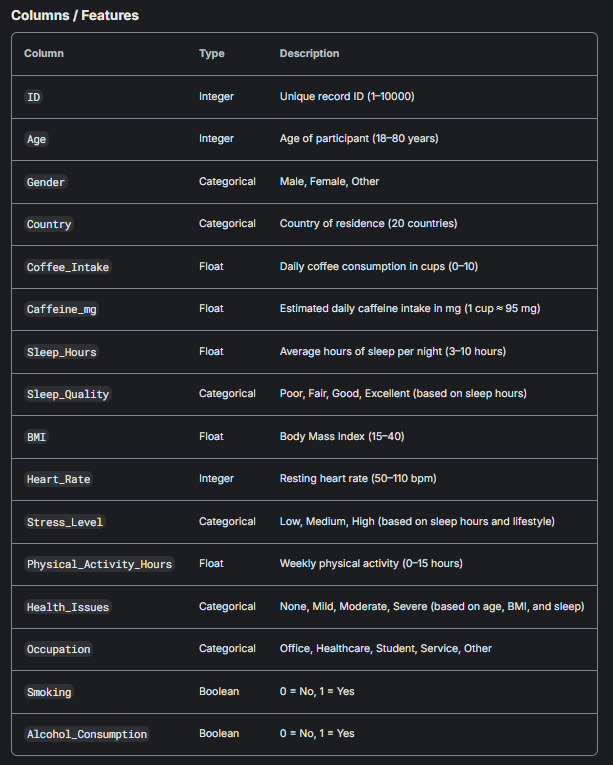

### **Innitial Assumption:**
- Does an increase in coffee consumption cause an increase in heart rate?
- A higher heart rate is related to overall health. 
- Typically a person who has high heart rate also has worse health and heart related problems since the heart must work harder.

### **Linear Regression for Causal Inferrence:**

> $y$ = $\beta_0$ + $\beta_1$ $D_i$ + $\epsilon_{it}$

$y$ = The outcome variable. The dependent variable.

$\beta_0$ = The outcome of the control group.

$\beta_1$ = The average difference in the change of the outcome between the treated and controlled groups. The average treatment effect ATE.

$D_i$ = The treatment variable, The independent variable. When $D_i$ = 1 = treated, when $D_i$ = 0 = control.

$\epsilon_i$ = The error term. Includes all unidentified cofounder variables.

### **Outcome Variable:**
- Heart_Rate, Integer, Resting heart rate (50–110 bpm).
- The variable measures the resting heart rate in beats per minute.
- It is the average heart rate when not performing physically demanding activities such as running or lifting weights.
- It is the "default" rate at which your hear beats.

### **Treatment Variable:**
- Coffee_Intake, Float, Daily coffee consumption in cups (0–10).
- Coffee intake is the average number of coffee cups consumed within the day.
- Its important to note that a cup of coffee does not explicitely mean a 1 cup measurment, which is 8 oz or 236.6 ml.
- A cup of coffee refers to 1 serving of coffee personally reported by someone.
- This 'serving' could be a small, medium, or large coffee you could purchase at Tim Hortons.
- However, a standard cup of coffee in the United States and Canada refers to the 8 oz or 236.6 ml measurment.

### **Possible Cofounders:**
- Age, Integer, Age of participant (18–80 years)
- Gender, Categorical, Male, Female, Other
- Country, Categorical, Country of residence (20 countries)
- Caffeine_mg, Float, Estimated daily caffeine intake in mg (1 cup ≈ 95 mg)
- Sleep_Hours, Float, Average hours of sleep per night (3–10 hours)
- Sleep_Quality, Categorical, Poor, Fair, Good, Excellent (based on sleep hours)
- BMI, Float, Body Mass Index (15–40)
- Stress_Level, Categorical, Low, Medium, High (based on sleep hours and lifestyle)
- Physical_Activity_Hours, Float, Weekly physical activity (0–15 hours)
- Health_Issues, Categorical, None, Mild, Moderate, Severe (based on age, BMI, and sleep)
- Occupation, Categorical, Office, Healthcare, Student, Service, Other
- Smoking, Boolean, 0 = No, 1 = Yes
- Alcohol_Consumption, Boolean, 0 = No, 1 = Yes

### **Linear Regression Equation for Problem:**
> Coffee_Intake = $\beta_0$ + $\beta_1$ (Heart_Rate) + $\beta_2$ (Age) + $\beta_3$ (Gender) + $\beta_4$ (Country) + $\beta_5$ (Caffeine_mg) + $\beta_6$ (Sleep_Hours) + $\beta_7$ (Sleep_Quality) + $\beta_8$ (BMI) + $\beta_9$ (Stress_Level) + $\beta_{10}$ (Physical_Activity_Hours) + $\beta_{11}$ (Health_Issues) + $\beta_{12}$ (Occupation) + $\beta_{13}$ (Smoking) + $\beta_{14}$ (Alcohol_Consumption) + $\epsilon_i$

---

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
import statsmodels.api as sm

## **Importing and Cleaning Data:**

In [57]:
df = pd.read_csv("C:\BROCK U COURSE DOCS\DataSets\synthetic_coffee_health_10000.csv")
df

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,50,Female,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,0,1
9996,9997,18,Female,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,0,0
9997,9998,26,Male,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,NaN,Student,1,1
9998,9999,40,Female,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,NaN,Student,0,0


In [58]:
df = df.drop(labels= 'ID', axis= 1)
df

,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,Female,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,0,1
9996,18,Female,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,0,0
9997,26,Male,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,NaN,Student,1,1
9998,40,Female,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,NaN,Student,0,0


> Removed the ID column. It is the same as the index.

In [59]:
df['Gender'].value_counts()

df['Male'] = (df['Gender'] == 'Male').astype(int)
df['Female'] = (df['Gender'] == 'Female').astype(int)

df = df.drop(labels= 'Gender', axis= 1)

df

,Age,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption,Male,Female
0,40,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0,1,0
1,33,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0,1,0
2,42,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0,1,0
3,53,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0,1,0
4,32,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,0,1,0,1
9996,18,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,0,0,0,1
9997,26,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,NaN,Student,1,1,1,0
9998,40,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,NaN,Student,0,0,0,1


> Created dummy variables for male and female genders. If both male and female are 0, then gender is 'other'.

In [60]:
country = pd.get_dummies(df['Country']).astype(int)

df = pd.merge(df, country, left_index= True, right_index= True)

df = df.drop(labels= 'Country', axis= 1)

df

,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption,Male,Female,Australia,Belgium,Brazil,Canada,China,Finland,France,Germany,India,Italy,Japan,Mexico,Netherlands,Norway,South Korea,Spain,Sweden,Switzerland,UK,USA
0,40,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,33,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,42,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,53,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,32,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
9996,18,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
9997,26,1.6,153.4,7.1,Good,25.1,66,Low,13.7,NaN,Student,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9998,40,3.4,327.1,7.0,Good,19.3,80,Low,0.1,NaN,Student,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


> Created country dummy variables.

In [61]:
df['Sleep_Quality'].value_counts()

df['Good_Sleep_Quality'] = (df['Sleep_Quality'] == 'Good').astype(int)
df['Poor_Sleep_Quality'] = (df['Sleep_Quality'] == 'Poor').astype(int)
df['Excellent_Sleep_Quality'] = (df['Sleep_Quality'] == 'Excellent').astype(int)

df = df.drop(labels= 'Sleep_Quality', axis= 1)
df

,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption,Male,Female,Australia,Belgium,Brazil,Canada,China,Finland,France,Germany,India,Italy,Japan,Mexico,Netherlands,Norway,South Korea,Spain,Sweden,Switzerland,UK,USA,Good_Sleep_Quality,Poor_Sleep_Quality,Excellent_Sleep_Quality
0,40,3.5,328.1,7.5,24.9,78,Low,14.5,NaN,Other,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,33,1.0,94.1,6.2,20.0,67,Low,11.0,NaN,Service,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,42,5.3,503.7,5.9,22.7,59,Medium,11.2,Mild,Office,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,53,2.6,249.2,7.3,24.7,71,Low,6.6,Mild,Other,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,32,3.1,298.0,5.3,24.1,76,Medium,8.5,Mild,Student,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,2.1,199.8,6.0,30.5,50,Medium,10.1,Moderate,Healthcare,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
9996,18,3.4,319.2,5.8,19.1,71,Medium,11.6,Mild,Service,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
9997,26,1.6,153.4,7.1,25.1,66,Low,13.7,NaN,Student,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
9998,40,3.4,327.1,7.0,19.3,80,Low,0.1,NaN,Student,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


> Created sleep quality dummy variables. If all are 0, then sleep quality is 'fair'.

In [62]:
df['Stress_Level'].value_counts()

df['Low_Stress_Level'] = (df['Stress_Level'] == 'Low').astype(int)
df['High_Stress_Level'] = (df['Stress_Level'] == 'High').astype(int)

df = df.drop(labels= 'Stress_Level', axis= 1)
df

,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption,Male,Female,Australia,Belgium,Brazil,Canada,China,Finland,France,Germany,India,Italy,Japan,Mexico,Netherlands,Norway,South Korea,Spain,Sweden,Switzerland,UK,USA,Good_Sleep_Quality,Poor_Sleep_Quality,Excellent_Sleep_Quality,Low_Stress_Level,High_Stress_Level
0,40,3.5,328.1,7.5,24.9,78,14.5,NaN,Other,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
1,33,1.0,94.1,6.2,20.0,67,11.0,NaN,Service,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
2,42,5.3,503.7,5.9,22.7,59,11.2,Mild,Office,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,53,2.6,249.2,7.3,24.7,71,6.6,Mild,Other,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
4,32,3.1,298.0,5.3,24.1,76,8.5,Mild,Student,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,2.1,199.8,6.0,30.5,50,10.1,Moderate,Healthcare,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9996,18,3.4,319.2,5.8,19.1,71,11.6,Mild,Service,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
9997,26,1.6,153.4,7.1,25.1,66,13.7,NaN,Student,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
9998,40,3.4,327.1,7.0,19.3,80,0.1,NaN,Student,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0


> Created dummy variables for stress level. If all are 0, then stress level is 'medium'.

In [63]:
df['Health_Issues'].value_counts()

df['Health_Issues'] = df['Health_Issues'].fillna('None')

df['Health_Issues'].value_counts()

Health_Issues
None        5941
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64

> Converted NaN values in health issues to none. If there was not a health issue recording, then it is automatically assumed there are no health issues.

In [64]:
df['No_Health_Issues'] = (df['Health_Issues'] == 'None').astype(int)
df['Mild_Health_Issues'] = (df['Health_Issues'] == 'Mild').astype(int)
df['Severe_Health_Issues'] = (df['Health_Issues'] == 'Severe').astype(int)

df = df.drop(labels= 'Health_Issues', axis= 1)
df

,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Occupation,Smoking,Alcohol_Consumption,Male,Female,Australia,Belgium,Brazil,Canada,China,Finland,France,Germany,India,Italy,Japan,Mexico,Netherlands,Norway,South Korea,Spain,Sweden,Switzerland,UK,USA,Good_Sleep_Quality,Poor_Sleep_Quality,Excellent_Sleep_Quality,Low_Stress_Level,High_Stress_Level,No_Health_Issues,Mild_Health_Issues,Severe_Health_Issues
0,40,3.5,328.1,7.5,24.9,78,14.5,Other,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0
1,33,1.0,94.1,6.2,20.0,67,11.0,Service,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0
2,42,5.3,503.7,5.9,22.7,59,11.2,Office,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,53,2.6,249.2,7.3,24.7,71,6.6,Other,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0
4,32,3.1,298.0,5.3,24.1,76,8.5,Student,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,2.1,199.8,6.0,30.5,50,10.1,Healthcare,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9996,18,3.4,319.2,5.8,19.1,71,11.6,Service,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
9997,26,1.6,153.4,7.1,25.1,66,13.7,Student,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0
9998,40,3.4,327.1,7.0,19.3,80,0.1,Student,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0


> Created dummy variables for health issues. If all are 0, then health issue is 'moderate'.

In [65]:
df['Occupation'].value_counts()

occupation = pd.get_dummies(df['Occupation']).astype(int)

df = pd.merge(df, occupation, left_index= True, right_index= True)

df = df.drop(labels= 'Occupation', axis= 1)

df

,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption,Male,Female,Australia,Belgium,Brazil,Canada,China,Finland,France,Germany,India,Italy,Japan,Mexico,Netherlands,Norway,South Korea,Spain,Sweden,Switzerland,UK,USA,Good_Sleep_Quality,Poor_Sleep_Quality,Excellent_Sleep_Quality,Low_Stress_Level,High_Stress_Level,No_Health_Issues,Mild_Health_Issues,Severe_Health_Issues,Healthcare,Office,Other,Service,Student
0,40,3.5,328.1,7.5,24.9,78,14.5,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0
1,33,1.0,94.1,6.2,20.0,67,11.0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0
2,42,5.3,503.7,5.9,22.7,59,11.2,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
3,53,2.6,249.2,7.3,24.7,71,6.6,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0
4,32,3.1,298.0,5.3,24.1,76,8.5,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,2.1,199.8,6.0,30.5,50,10.1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
9996,18,3.4,319.2,5.8,19.1,71,11.6,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0
9997,26,1.6,153.4,7.1,25.1,66,13.7,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1
9998,40,3.4,327.1,7.0,19.3,80,0.1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1


> Added occupation dummy variables.


---

## **Linear Regression Model:**

In [66]:
df.columns

Index(['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI',
       'Heart_Rate', 'Physical_Activity_Hours', 'Smoking',
       'Alcohol_Consumption', 'Male', 'Female', 'Australia', 'Belgium',
       'Brazil', 'Canada', 'China', 'Finland', 'France', 'Germany', 'India',
       'Italy', 'Japan', 'Mexico', 'Netherlands', 'Norway', 'South Korea',
       'Spain', 'Sweden', 'Switzerland', 'UK', 'USA', 'Good_Sleep_Quality',
       'Poor_Sleep_Quality', 'Excellent_Sleep_Quality', 'Low_Stress_Level',
       'High_Stress_Level', 'No_Health_Issues', 'Mild_Health_Issues',
       'Severe_Health_Issues', 'Healthcare', 'Office', 'Other', 'Service',
       'Student'],
      dtype='object')

In [67]:
y = df['Heart_Rate']

x = df[['Coffee_Intake', 'Age', 'Caffeine_mg', 'Sleep_Hours', 'BMI',
       'Physical_Activity_Hours', 'Smoking',
       'Alcohol_Consumption', 'Male', 'Female', 'Australia', 'Belgium',
       'Brazil', 'Canada', 'China', 'Finland', 'France', 'Germany', 'India',
       'Italy', 'Japan', 'Mexico', 'Netherlands', 'Norway', 'South Korea',
       'Spain', 'Sweden', 'Switzerland', 'UK', 'USA', 'Good_Sleep_Quality',
       'Poor_Sleep_Quality', 'Excellent_Sleep_Quality', 'Low_Stress_Level',
       'High_Stress_Level', 'No_Health_Issues', 'Mild_Health_Issues',
       'Severe_Health_Issues', 'Healthcare', 'Office', 'Other', 'Service',
       'Student']]

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Heart_Rate   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.966
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           0.000310
Time:                        19:46:14   Log-Likelihood:                -36998.
No. Observations:               10000   AIC:                         7.408e+04
Df Residuals:                    9960   BIC:                         7.436e+04
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      56.6480      1.357     41.758      0.000      53.989      59.307
Coffee_Intake               2.2456      3.509      0.640      0.522      -4.632       9.124
Age                        -0.0002      0.010     -0.019      0.985      -0.020       0.020
Caffeine_mg                -0.0197      0.037     -0.533      0.594      -0.092       0.053
Sleep_Hours                -0.0126      0.201     -0.063      0.950      -0.407       0.382
BMI                        -0.0244      0.027     -0.902      0.367      -0.077       0.029
Physical_Activity_Hours    -0.0077      0.023     -0.337      0.736      -0.052       0.037
Smoking                     0.1678      0.246      0.683      0.494      -0.314       0.649
Alcohol_Consumption        -0.1930      0.214     -0.900      0.368      -0.613       0.227
Male                        0.3970      0.669      0.594      0.553      -0.913       1.707
Female                      0.5227      0.668      0.783      0.434      -0.786       1.832
Australia                   2.4090      0.435      5.535      0.000       1.556       3.262
Belgium                     3.0614      0.435      7.037      0.000       2.209       3.914
Brazil                      3.3662      0.452      7.447      0.000       2.480       4.252
Canada                      3.1083      0.417      7.448      0.000       2.290       3.926
China                       2.3898      0.425      5.622      0.000       1.556       3.223
Finland                     3.5464      0.429      8.266      0.000       2.705       4.387
France                      2.0975      0.435      4.819      0.000       1.244       2.951
Germany                     3.4271      0.433      7.907      0.000       2.578       4.277
India                       2.6009      0.424      6.137      0.000       1.770       3.432
Italy                       2.6700      0.430      6.210      0.000       1.827       3.513
Japan                       1.7904      0.446      4.017      0.000       0.917       2.664
Mexico                      3.2792      0.440      7.455      0.000       2.417       4.141
Netherlands                 2.3286      0.436      5.338      0.000       1.473       3.184
Norway                      3.1187      0.424      7.350      0.000       2.287       3.950
South Korea                 2.4444      0.429      5.698      0.000       1.603       3.285
Spain                       3.1139      0.439      7.089      0.000       2.253       3.975
Sweden                      3.1178      0.427      7.302      0.000       2.281       3.955
Switzerland                 2.8312      0.432      6.558      0.000       1.985       3.677
UK                          3.2120      0.426      7.546      0.000       2.378       4.046
USA                         2.7352      0.456  

## **Conclusion:**

### **Linear Regression Equation for Problem:**
> Heart_Rate = 56.6480 + 2.2456 (Coffee_Intake) + $\beta_2$ (Age) + $\beta_3$ (Gender) + $\beta_4$ (Country) + $\beta_5$ (Caffeine_mg) + $\beta_6$ (Sleep_Hours) + $\beta_7$ (Sleep_Quality) + $\beta_8$ (BMI) + $\beta_9$ (Stress_Level) + $\beta_{10}$ (Physical_Activity_Hours) + $\beta_{11}$ (Health_Issues) + $\beta_{12}$ (Occupation) + $\beta_{13}$ (Smoking) + $\beta_{14}$ (Alcohol_Consumption) + $\epsilon_i$

### **Hypothesis Test for Treatment Beta Coefficient Significance:**

Ho: Population change in heart rate from an increase in coffee intake $\beta_1$ = 0

Ha: Population change in heart rate from an increase in coffee intake $\beta_1$ != 0

t-stat = ($\beta_1$ - 0) / SE[$\beta_1$]

t-stat = (2.2456 - 0) / 3.509

t-stat = 0.640

p-value = The probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true.

p-value = 0.522

$\alpha$ = 0.05

=> p-value > $\alpha$

=> 0.522 > 0.05

=> We fail to reject the null hypothesis; Population change in heart rate from an increase in coffee intake $\beta_1$ = 0

### **Confidence Interval for Treatment Beta Coefficient:**

Confidence Interval = [-4.632, 9.124]

=> Confidence interval does contain zero and therefore these results confirm the hypothesis test that $\beta_1$ = 0.

### **Description, Reasoning, and Summary:**
- The model does confirm the relationship proposed in the initial assumption, which states that an increase in daily cups of coffee intake will lead to an increase in average resting heart rate per minute.
- The model shows that the average change in the heart rate from one cup increase in coffee intake per day is 2.2456 beats per minute.
- In other words, as coffee intake increases by one cup, the average heart beats per minute will increase by 2.2456 beats per minute.
- However, the main issue is that this relationship is not statistically significant.
- The difference between the sample $\beta_1$ and zero, given the standard deviation, is low, which tells us that the sample $\beta_1$ is very close to zero.
- Since this is the case, the probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true, is high.
- This is because we assume the null hypothesis is in fact true, and that the population $\beta_1$ is equal to zero.
- This does seem to be the case and the sample $\beta_1$ does confirm the null to be true.
- The sample $\beta_1$ is very close to zero, and it confirms the truth of the null hypothesis. The null hypothesis of the population $\beta_1$ accuratly represent the sample data.
- Therefore the null hypothesis has failed to be rejected. The population average change in the outcome $\beta_1$ is zero.
- Since there is no statistical significance of the relationship between coffee intake and heart rate, there cannot possibly be any evidence for a causal effect.
- We assume the sample data is collected at random, however the treatment is not assigned randomly since people choose to drink however many cups of coffee they want at their own will.
- Therefore, we must control for all possible significant cofounders that may exist, which is impossible.
- Since there is no statistical significance of a relationship between coffee intake and heart rate, and the fact that treatment is not assigned randomly and we cannot control for all possible cofounder, we cannot possibly conclude this relationship is causal at all.
- To conclude, there is no relationship between coffee intake and heart rate, and there is no causal effect which states the more cups of coffee ingested, the higher your heart rate will be and therefore the poorer your overall health will get.